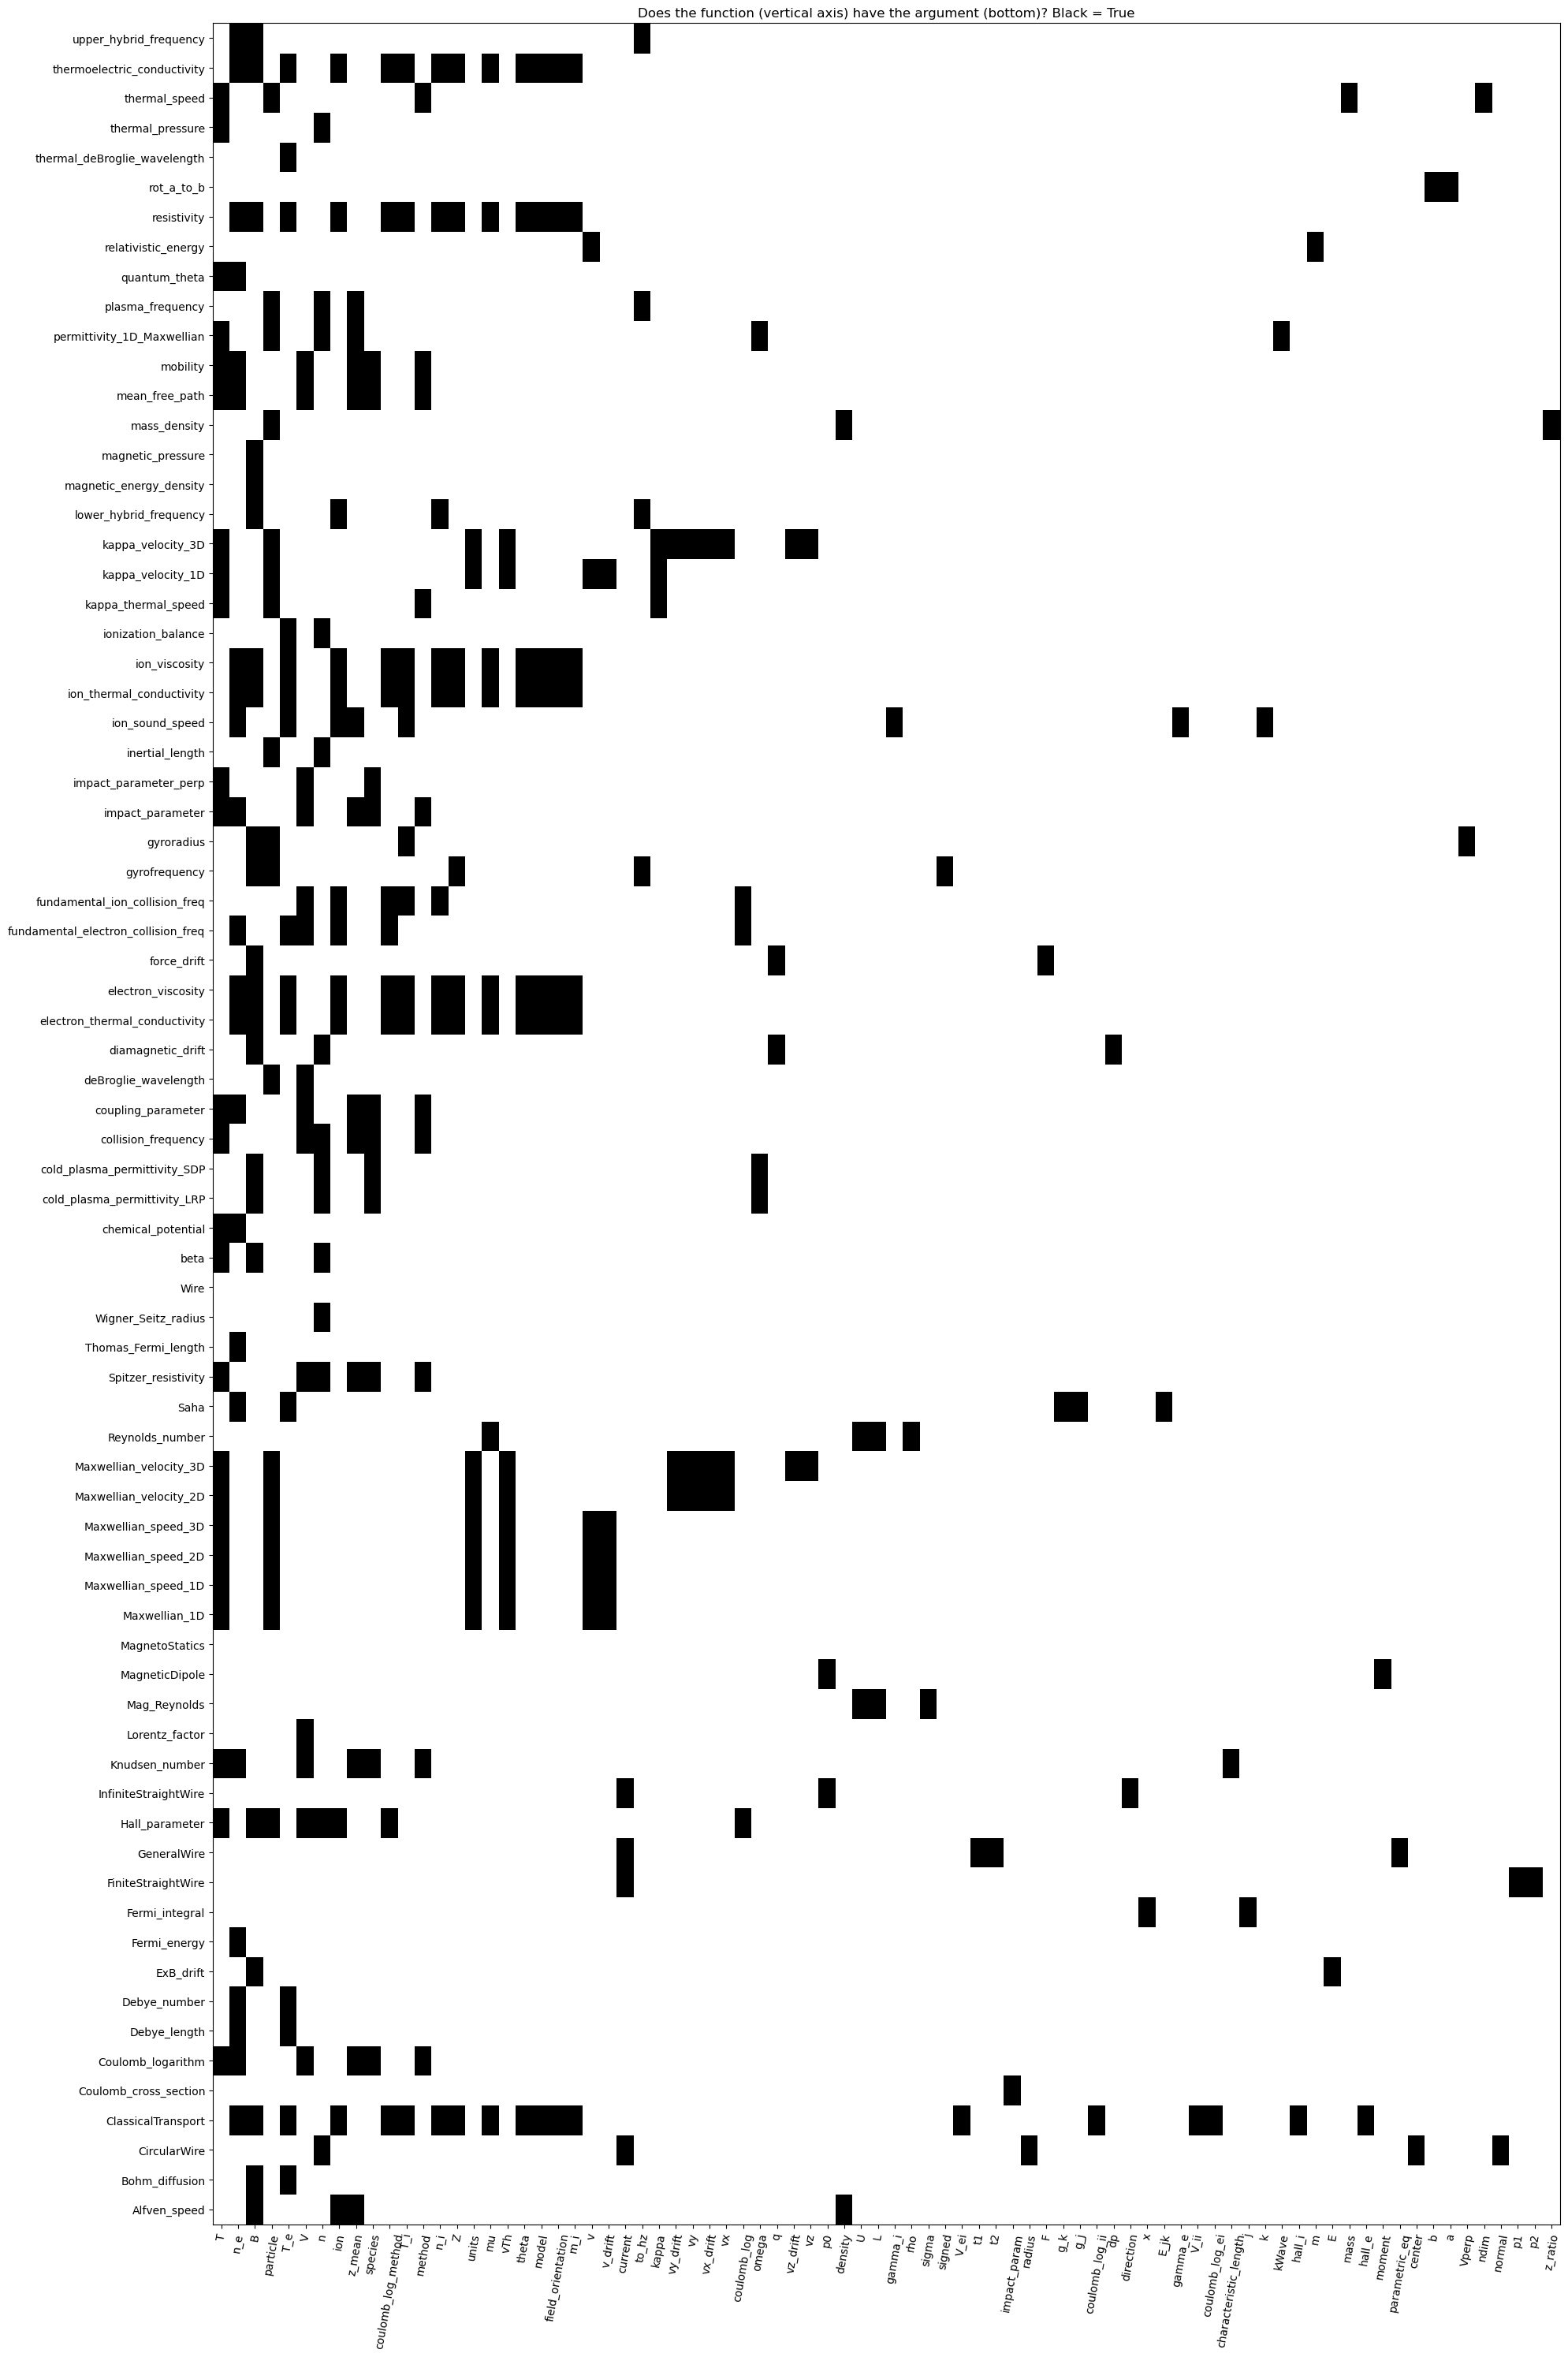

In [149]:
import inspect

from plasmapy import formulary
from plasmapy.formulary import parameters

results = {}
for name, function in inspect.getmembers(
    formulary,
    lambda member: callable(member)
    #                                          and "parameters" in member.__module__
):
    if name.endswith("_") or name.startswith("_"):
        continue
    try:
        results[name] = inspect.signature(function)
    except:
        print(name)

arg_names = {function: list(sig.parameters.keys()) for function, sig in results.items()}

import itertools

all_argument_names = sorted(list(set(list(itertools.chain(*list(arg_names.values()))))))

has_argument = np.zeros((len(arg_names), len(all_argument_names)), dtype=bool)
for i, (function_name, function_signature) in enumerate(arg_names.items()):
    for arg in function_signature:
        has_argument[i, all_argument_names.index(arg)] = True

import pandas as pd

df = pd.DataFrame(has_argument, index=arg_names.keys(), columns=all_argument_names)

arguments_occur_this_many_times = df.sum(axis=0)

arguments_sort = arguments_occur_this_many_times.sort_values(ascending=False)

df = df.reindex(columns=arguments_sort.index)

plt.figure(figsize=(20, 30))
plt.pcolor(df, cmap="binary")
plt.yticks(np.arange(0.5, len(df.index), 1), df.index)
plt.xticks(np.arange(0.5, len(df.columns), 1), df.columns, rotation=80)
plt.title("Does the function (vertical axis) have the argument (bottom)? Black = True")
plt.tight_layout()
plt.savefig("/tmp/picture.png")
plt.show()